<a href="https://colab.research.google.com/github/MhiyaJ/My-GIS-Stuff/blob/main/PS01_Camden_County_After_School_Programs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%%capture
#!pip install geopandas #==1.0.1
#!pip install mapclassify #sometimes have to install library which you get from https://pypi.org/

In [3]:
import os, zipfile #basics
import pandas as pd #data management
import matplotlib.pyplot as plt #vis

import geopandas as gpd #gis/maps: a sister of pandas; does the job;
#tho not as fancy-interactive as folium or leafmap https://geopandas.org/

import mapclassify #need for thematic map classification

import seaborn as sns

#will display all output not just last command
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from google.colab import files #to download from colab onto hd

#from google.colab import data_table
#data_table.enable_dataframe_formatter() #this enables spreadsheet view upon calling dataframe (without() )
from google.colab.data_table import DataTable
DataTable.max_columns = 250

In [4]:
#!python --version
gpd.__version__

'1.1.4'

**Hypothesis**: Limited access to affordable after-school programs contributes to increased social disengagement and delinquent behavior among students living in urban areas.

**Project Description:** Identifying the availability and accessibility of after school programs in low income areas and examining their relationship to youth social disengagement and delinquent behaviors.  

*Variables:* After school programs, economically disadvantaged youth population, delinquent/disengaged behavior, household income

In [5]:
#Camden County Open Data Portal, Municipalities, Retrieved: September 16, 2026
#https://camdencountynj-ccdpw.opendata.arcgis.com/datasets/CCDPW::municipalities/about
! wget -q -O Municipalities.zip https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Municipalities.zip
zip_ref = zipfile.ZipFile('Municipalities.zip', 'r'); zip_ref.extractall(); zip_ref.close()

njMun=gpd.read_file('Municipalities.shp') #labeled shapefile njSch

<Axes: >

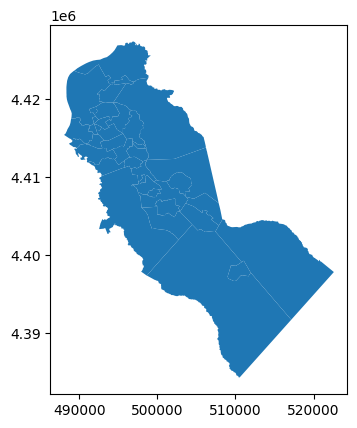

In [6]:
njMun.plot()

In [9]:
njMun.dtypes #Municipality Headings

,0
FID,int32
COUSUBNS,object
GEOID,object
NAMELSAD,object
CLASSFP,object
FUNCSTAT,object
ALAND,int32
AWATER,int32
INTPTLAT,object
INTPTLON,object


In [21]:
#36 Municipalities in Camden County
njMun.iloc[list(range(0, 36))]

,FID,COUSUBNS,GEOID,NAMELSAD,CLASSFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,Shape_Leng,GEOCODE,GlobalID,Shape__Are,Shape__Len,geometry
0,1,00885144,3400702200,Audubon borough,C5,F,3838781,35535,+39.8901277,-75.0723825,9407.757950,3400702200,81d661c6-35a7-42ed-8afd-5f35d0b0e807,3.871214e+06,9407.757866,"POLYGON ((495599.23 4415536.249, 495508.749 44..."
1,2,00885145,3400702230,Audubon Park borough,C5,F,389606,46935,+39.8968373,-75.0888190,2734.677596,3400702230,f8ccbea8-76dd-44e7-992b-e367d22e31a1,4.361934e+05,2734.677499,"POLYGON ((492866.221 4416337.872, 492855.687 4..."
2,3,00885149,3400703250,Barrington borough,C5,F,4095340,0,+39.8689349,-75.0513618,11456.984021,3400703250,9e9086b1-16e4-429f-b5c4-d967de1dbd82,4.092067e+06,11456.984073,"POLYGON ((496819.374 4414558.505, 496827.878 4..."
3,4,00885154,3400704750,Bellmawr borough,C5,F,7729295,315734,+39.8663560,-75.0946695,18085.471872,3400704750,bdd07346-3ee8-471e-befd-b8b9e16eb0a9,8.038608e+06,18085.472003,"POLYGON ((492951.896 4413667.751, 492968.147 4..."
4,5,00885158,3400705440,Berlin borough,C5,F,9307767,35573,+39.7920594,-74.9369855,14823.777678,3400705440,032f4608-e579-4343-a5e1-7d3778ce56c5,9.335884e+06,14823.777540,"POLYGON ((507881.319 4403761.193, 507873.371 4..."
5,6,00882152,3400705470,Berlin township,T1,A,8656740,15360,+39.8071159,-74.9241780,15771.555136,3400705470,e17a4101-16d7-4093-b9da-43f1044ceef7,8.665170e+06,15771.555122,"POLYGON ((507848.567 4406644.366, 507978.687 4..."
6,7,00885172,3400708170,Brooklawn borough,C5,F,1265110,105763,+39.8793503,-75.1203958,5697.800517,3400708170,1e1a2ee3-3807-458d-8af0-7a2d5df7de30,1.369780e+06,5697.800436,"POLYGON ((490740.818 4414218.502, 490736.285 4..."
7,8,00885177,3400710000,Camden city,C5,F,23106182,3676392,+39.9367868,-75.1066438,28004.054276,3400710000,f5c8c982-1593-4592-a38a-485a23bd7d98,2.676122e+07,28004.054367,"POLYGON ((493032.266 4419551.728, 492897.768 4..."
8,9,00882155,3400712280,Cherry Hill township,T1,A,62346260,321495,+39.9046107,-74.9969997,42634.513569,3400712280,561f8439-f9d9-47af-a877-f4c81e30fd7a,6.261764e+07,42634.513259,"POLYGON ((506224.674 4413748.279, 506174.32 44..."
9,10,00885183,3400712550,Chesilhurst borough,C5,F,4442825,4000,+39.7297952,-74.8805311,9002.409548,3400712550,db06a511-84e0-41f6-a5d9-e8afa47e852f,4.443282e+06,9002.409554,"POLYGON ((512006.451 4397643.342, 512016.246 4..."


In [5]:
#keep it simple! always do it! and do it early!
njMun=njMun1[['COUNTY','COUNTY_LAB','POP2010','POPDEN2010','geometry']]

NameError: name 'njMun1' is not defined

In [6]:
#Camden County Open Data Portal, Schools, Retrieved: September 16, 2026
#https://camdencountynj-ccdpw.opendata.arcgis.com/datasets/CCDPW::schools/about
! wget -q -O Schools.zip https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Schools.zip
zip_ref = zipfile.ZipFile('Schools.zip', 'r'); zip_ref.extractall(); zip_ref.close()

njSch=gpd.read_file('Schools.shp') #labeled shapefile njSch

<Axes: >

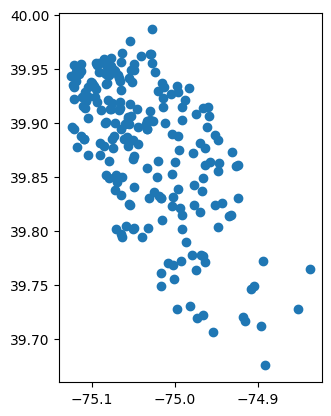

In [7]:
njSch.plot()

In [8]:
njSch.dtypes #School District Headings

,0
OBJECTID_1,int32
OBJECTID,int32
COUNTYCODE,object
COUNTY,object
DIST_CODE,object
DIST_NAME,object
SCHOOLCODE,object
SCHOOLTYPE,object
SCHOOL,object
ADDRESS1,object


In [9]:
njSch.head(1)

,OBJECTID_1,OBJECTID,COUNTYCODE,COUNTY,DIST_CODE,DIST_NAME,SCHOOLCODE,SCHOOLTYPE,SCHOOL,ADDRESS1,...,SOURCE,ZIP_TRUNC,PREF_ID_NU,GNIS_ID,LOC_QUAL,OGIS_ID,CATEGORY,SCHOOLNAME,LAST_UPDAT,geometry
0,1,2512,07,CAMDEN,0580,Brooklawn Public School District,010,ELEMENTARY SCHOOL,ALICE COSTELLO E.S.,301 Haakon rd.,...,PUBLIC,08030,0580-010-07,None,H,07-0580-010,3,Alice Costello Elementary School,2017-03-02T14:10:01Z,POINT (-75.11856 39.87817)


In [10]:
#School Districts
njSch.iloc[list(range(0,225))]

,OBJECTID_1,OBJECTID,COUNTYCODE,COUNTY,DIST_CODE,DIST_NAME,SCHOOLCODE,SCHOOLTYPE,SCHOOL,ADDRESS1,...,SOURCE,ZIP_TRUNC,PREF_ID_NU,GNIS_ID,LOC_QUAL,OGIS_ID,CATEGORY,SCHOOLNAME,LAST_UPDAT,geometry
0,1,2512,07,CAMDEN,0580,Brooklawn Public School District,010,ELEMENTARY SCHOOL,ALICE COSTELLO E.S.,301 Haakon rd.,...,PUBLIC,08030,0580-010-07,None,H,07-0580-010,3,Alice Costello Elementary School,2017-03-02T14:10:01Z,POINT (-75.11856 39.87817)
1,2,2513,07,CAMDEN,0680,Camden City Public Schools,301,ELEMENTARY SCHOOL,HENRY L. BONSALL FAMILY SCHOOL,1575 Mount Ephraim Avenue,...,PUBLIC,08104,0680-301-07,None,H,07-0680-301,3,Bonsall Elementary School,2017-03-02T14:10:01Z,POINT (-75.106 39.9254)
2,3,2514,07,CAMDEN,0680,Camden City Public Schools,029,HIGH SCHOOL-OTHER,BRIMM MEDICAL ARTS H.S.,1626 Copewood Street,...,PUBLIC,08103,0680-029-07,None,H,07-0680-029,3,Brimm Medical Arts High School,2017-03-02T14:10:01Z,POINT (-75.0958 39.92384)
3,4,2515,07,CAMDEN,0680,Camden City Public Schools,030,FOUR-YEAR HIGH SCHOOL,CAMDEN H.S.,1700 Park Boulevard,...,PUBLIC,08103,0680-030-07,None,H,07-0680-030,3,Camden High School,2017-03-02T14:10:01Z,POINT (-75.09841 39.93536)
4,5,2516,07,CAMDEN,0680,Camden City Public Schools,165,ELEMENTARY SCHOOL,COOPER'S POYNT E.S.,201 State Street,...,PUBLIC,08102,0680-165-07,None,H,07-0680-165,3,Cooper's Poynt Elementary School,2017-03-02T14:10:01Z,POINT (-75.12148 39.95406)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,221,752,08,CAMDEN,0283,Winslow Twp,60C,None,LITTLEST ANGELS SCHOOL,428 Sicklerville Road,...,PRIVATE,08081,0283-60C-08,None,H,08-0283-60C,2,Littlest Angels School,2017-03-02T14:10:00Z,POINT (-74.97358 39.71979)
221,222,1059,08,CAMDEN,1828,Stratford Boro,07B,None,JOHN PAUL REGIONAL SCHOOL,55 Warwick Road,...,PRIVATE,08084,1828-07B-08,None,H,08-1828-07B,2,John Paul Regional School,2017-03-02T14:10:00Z,POINT (-75.01718 39.83079)
222,223,1088,08,CAMDEN,1895,Haddonfield Boro,09W,None,THE BEECHWOOD SCHOOL,441 Beechwood Ave,...,PRIVATE,08033,1895-09W-08,None,H,08-1895-09W,2,The Beechwood School,2017-03-02T14:10:00Z,POINT (-75.03056 39.91082)
223,224,1094,08,CAMDEN,1876,Winslow Twp,09C,None,TLBU INTERNATIONAL HIGH SCHOOL,41 South Route 73,...,PRIVATE,08018,1876-09C-08,None,H,08-1876-09C,2,Transnational Law & Business University - Inte...,2017-03-02T14:10:00Z,POINT (-74.89647 39.71248)


In [11]:
DisXls=pd.read_excel ('https://github.com/MhiyaJ/My-GIS-Stuff/raw/refs/heads/main/Economically%20Disadvantage%20Youth%202024%20-%202025.xlsx')

In [12]:
DisXls.head (2)

,"This worksheet contains one table spanning columns A through O, with row 4 as the header row.",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
0,EnrollmentTrendsByStudentGroup: District/State...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Note:,Data appears in the Enrollment and Demographic...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
DisXls.dtypes

,0
"This worksheet contains one table spanning columns A through O, with row 4 as the header row.",object
Unnamed: 1,object
Unnamed: 2,object
Unnamed: 3,object
Unnamed: 4,object
Unnamed: 5,object
Unnamed: 6,object
Unnamed: 7,object
Unnamed: 8,object
Unnamed: 9,object


In [16]:
DisXls1=DisXls[['This worksheet contains one table spanning columns A through O, with row 4 as the header row.', 'Unnamed: 14']]
DisXls1.rename(columns={'This worksheet contains one table spanning columns A through O, with row 4 as the header row.' : 'CountyCode'}, inplace=True)
DisXls1.rename(columns={'Unnamed: 14' : 'Migrant Students'}, inplace=True)
DisXls1


/tmp/ipykernel_3411/3659986859.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DisXls1.rename(columns={'This worksheet contains one table spanning columns A through O, with row 4 as the header row.' : 'CountyCode'}, inplace=True)
/tmp/ipykernel_3411/3659986859.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DisXls1.rename(columns={'Unnamed: 14' : 'Migrant Students'}, inplace=True)


,CountyCode,Migrant Students
0,EnrollmentTrendsByStudentGroup: District/State...,NaN
1,Note:,NaN
2,CountyCode,Migrant Students
3,07,0%
4,07,0%
5,07,0%
6,07,0%
7,07,0%
8,07,0%
9,07,0%
